# Q2 日曲线 PCA + Ridge 预测 —— 最终冻结版

> **用途**：替换旧的 `02_日曲线PCA岭回归预测.ipynb`。  
> 旧版中的 `W=120, K_L=K_P=6, α=10` 等参数不再作为最终模型。

最终冻结结构：

$$
W=60,\qquad K_L=3,\qquad K_P=2
$$

$$
h_L=\mathrm{lag1}
$$

$$
h_P=\mathrm{lag1}+\mathrm{lag7}+\mathrm{mean7}
$$

$$
C_L=\mathrm{weekday7},\qquad C_P=\mathrm{annual1}
$$

$$
\alpha_L=0.3,\qquad \alpha_P=10
$$

其中 $W=60$ 表示**最大历史窗口长度**。在启动阶段历史不足 60 天时，使用当时全部已完成历史；历史达到 60 天后转为固定 60 日滚动窗口。

本 Notebook 只负责最终 **PCA + Ridge 点预测模型**及其评价，不负责风险分位数 $q^*$ 与储能调度；后者由 `Q2_风险分位数策略_最终版.ipynb` / `p2.py` 完成。


In [13]:
from pathlib import Path
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

plt.rcParams["axes.unicode_minus"] = False

ROOT = Path.cwd()

def find_file(names):
    """
    自动寻找输入文件，兼容：
    - q2/input/
    - q2/
    - 当前目录
    - 上一级目录
    """
    search_dirs = [
        ROOT / "input",
        ROOT,
        ROOT.parent / "q2" / "input",
        ROOT.parent / "q2",
        ROOT.parent,
    ]
    tried = []
    for d in search_dirs:
        for name in names:
            p = d / name
            tried.append(p)
            if p.exists():
                print(f"[找到输入] {p}")
                return p

    # 有限递归搜索，避免 VS Code 工作目录与 Notebook 所在目录不同
    for d in [ROOT, ROOT.parent]:
        if d.exists():
            for name in names:
                matches = list(d.glob(f"**/{name}"))
                if matches:
                    print(f"[递归找到输入] {matches[0]}")
                    return matches[0]

    msg = "\n".join(f"  - {p}" for p in tried)
    raise FileNotFoundError(
        "未找到 Q2 实际负荷/PV 数据。\n"
        f"当前工作目录：{ROOT}\n"
        f"已尝试：\n{msg}"
    )

ACTUAL_PATH = find_file([
    "q2_actual_load_pv.csv",
    "q2_actual_load_pv(1).csv",
])

print("ROOT =", ROOT)
print("ACTUAL_PATH =", ACTUAL_PATH)


[找到输入] e:\桌面\CUMCM_2026\q2\input\q2_actual_load_pv.csv
ROOT = e:\桌面\CUMCM_2026\q2
ACTUAL_PATH = e:\桌面\CUMCM_2026\q2\input\q2_actual_load_pv.csv


## 1. 数据读取与完整性检查

附件 2 按 10 分钟采样，每天 144 个时段，全年应有

$$
365\times144=52{,}560
$$

条记录。Load 与 PV 均以 kW 为单位。


In [14]:
df = pd.read_csv(ACTUAL_PATH, encoding="utf-8-sig")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["date", "slot"]).reset_index(drop=True)

assert len(df) == 365 * 144, f"行数异常: {len(df)}"
assert df[["load_kw", "pv_kw"]].notna().all().all(), "存在缺失值"
assert (df[["load_kw", "pv_kw"]] >= 0).all().all(), "存在负 Load/PV"
assert df[["date", "slot"]].duplicated().sum() == 0, "存在重复 date-slot"

counts = df.groupby("date")["slot"].nunique()
assert (counts == 144).all(), "存在某日不是144个时段"

DATES = pd.DatetimeIndex(df["date"].drop_duplicates())
LOAD = df["load_kw"].to_numpy(float).reshape(-1, 144)
PV = df["pv_kw"].to_numpy(float).reshape(-1, 144)

print(f"日期范围: {DATES.min().date()} ~ {DATES.max().date()}")
print(f"天数: {len(DATES)}")
print(f"总记录: {len(df)}")
print(f"Load范围: {LOAD.min():.4f} ~ {LOAD.max():.4f} kW")
print(f"PV范围: {PV.min():.4f} ~ {PV.max():.4f} kW")


日期范围: 2025-01-01 ~ 2025-12-31
天数: 365
总记录: 52560
Load范围: 1995.7176 ~ 7978.8849 kW
PV范围: 0.0000 ~ 10216.2000 kW


## 2. 最终冻结参数

最终参数来自公共开发区间上的联合搜索、逐参数 Profile 分析与分月稳定性检查。

注意：这里**不再重新调参**，只按已经冻结的参数重新计算预测并评价。


In [15]:
CFG = {
    "window_days": 60,
    "k_load": 3,
    "k_pv": 2,
    "alpha_load": 0.3,
    "alpha_pv": 10.0,
}

DEV_START = pd.Timestamp("2025-05-01")
DEV_END   = pd.Timestamp("2025-08-31")

TEST_START = pd.Timestamp("2025-09-01")
TEST_END   = pd.Timestamp("2025-12-31")

pd.DataFrame([{
    "W": CFG["window_days"],
    "K_L": CFG["k_load"],
    "K_P": CFG["k_pv"],
    "h_L": "lag1",
    "h_P": "lag1+lag7+mean7",
    "C_L": "weekday7",
    "C_P": "annual1",
    "alpha_L": CFG["alpha_load"],
    "alpha_P": CFG["alpha_pv"],
}])


,W,K_L,K_P,h_L,h_P,C_L,C_P,alpha_L,alpha_P
0,60,3,2,lag1,lag1+lag7+mean7,weekday7,annual1,0.3,10.0


## 3. 模型结构

对 Load 与 PV 分别在每个预测日的历史窗口中重新拟合 PCA：

$$
L_d
\approx
\mu_L+
\sum_{k=1}^{K_L}
s^L_{d,k}\phi^L_k
$$

$$
P_d
\approx
\mu_P+
\sum_{k=1}^{K_P}
s^P_{d,k}\phi^P_k
$$

随后使用 Ridge 回归预测 PCA score。

Load 使用：

$$
x^L_d
=
\left[
\mathrm{weekday7}(d),
\ s^L_{d-1}
\right]
$$

PV 使用：

$$
x^P_d
=
\left[
\mathrm{annual1}(d),
\ s^P_{d-1},
\ s^P_{d-7},
\ \overline{s^P}_{d-7:d-1}
\right]
$$

所有 PCA、Scaler 与 Ridge 均只使用预测日 $d$ 之前的数据。


In [16]:
def pca_basis(curves, k):
    mu = curves.mean(axis=0)
    _, _, vt = np.linalg.svd(curves - mu, full_matrices=False)
    return mu, vt[:k]

def weekday7(date):
    x = np.zeros(7)
    x[date.weekday()] = 1.0
    return x

def annual1(date):
    a = 2 * np.pi * date.dayofyear / 365.25
    return np.array([np.sin(a), np.cos(a)])

def rolling_forecast(dates, load, pv, cfg):
    """
    与最终 p2.py 保持一致的因果滚动预测。

    W=60 为最大窗口：
    h0 = max(0, d-W)

    因此：
    - 启动阶段：使用全部可用历史
    - 历史达到60天后：固定60日滚动窗口
    """
    W = int(cfg["window_days"])
    KL = int(cfg["k_load"])
    KP = int(cfg["k_pv"])
    AL = float(cfg["alpha_load"])
    AP = float(cfg["alpha_pv"])

    pred_l = np.full_like(load, np.nan)
    pred_p = np.full_like(pv, np.nan)

    # 至少需要 lag7 + 一定训练样本
    for d in range(14, len(dates)):
        h0 = max(0, d - W)

        # 只用 [h0, d) 历史日拟合 PCA
        mu_l, phi_l = pca_basis(load[h0:d], KL)
        mu_p, phi_p = pca_basis(pv[h0:d], KP)

        # score 只对应历史窗口
        sl = (load[h0:d] - mu_l) @ phi_l.T
        sp = (pv[h0:d] - mu_p) @ phi_p.T

        train_days = np.arange(max(h0 + 7, 7), d)

        def f_load(j):
            jj = j - h0
            return np.r_[
                weekday7(dates[j]),
                sl[jj - 1],
            ]

        def f_pv(j):
            jj = j - h0
            return np.r_[
                annual1(dates[j]),
                sp[jj - 1],
                sp[jj - 7],
                sp[jj - 7:jj].mean(axis=0),
            ]

        XL = np.vstack([f_load(j) for j in train_days])
        XP = np.vstack([f_pv(j) for j in train_days])

        yL = np.vstack([sl[j - h0] for j in train_days])
        yP = np.vstack([sp[j - h0] for j in train_days])

        model_l = make_pipeline(
            StandardScaler(),
            Ridge(alpha=AL),
        )
        model_p = make_pipeline(
            StandardScaler(),
            Ridge(alpha=AP),
        )

        model_l.fit(XL, yL)
        model_p.fit(XP, yP)

        sL_hat = np.atleast_1d(
            model_l.predict(f_load(d)[None, :])[0]
        )
        sP_hat = np.atleast_1d(
            model_p.predict(f_pv(d)[None, :])[0]
        )

        pred_l[d] = np.maximum(
            mu_l + sL_hat @ phi_l,
            0,
        )
        pred_p[d] = np.maximum(
            mu_p + sP_hat @ phi_p,
            0,
        )

    return pred_l, pred_p

PRED_LOAD, PRED_PV = rolling_forecast(
    DATES, LOAD, PV, CFG
)

print("滚动预测完成。")


滚动预测完成。


## 4. 开发期与样本外测试期指标

统一使用所有 10 分钟时段的数据计算 pooled MAE / RMSE：

$$
\mathrm{MAE}
=
\frac{1}{N}
\sum_{i=1}^{N}
\left|
y_i-\hat{y}_i
\right|
$$

$$
\mathrm{RMSE}
=
\sqrt{
\frac{1}{N}
\sum_{i=1}^{N}
\left(
y_i-\hat{y}_i
\right)^2
}
$$

其中，净负荷定义为：

$$
N_t
=
L_t-P_t^{\mathrm{PV}}
$$

即小区负荷减去光伏发电功率。


In [17]:
def metric_block(days):
    yL = LOAD[days]
    yP = PV[days]
    pL = PRED_LOAD[days]
    pP = PRED_PV[days]

    yN = yL - yP
    pN = pL - pP

    def m(y, p):
        return (
            float(np.mean(np.abs(y - p))),
            float(np.sqrt(np.mean((y - p) ** 2))),
        )

    L_mae, L_rmse = m(yL, pL)
    P_mae, P_rmse = m(yP, pP)
    N_mae, N_rmse = m(yN, pN)

    return pd.DataFrame([
        ["Load", L_mae, L_rmse],
        ["PV", P_mae, P_rmse],
        ["Net Load", N_mae, N_rmse],
    ], columns=["对象", "MAE_kW", "RMSE_kW"])

DEV_IDX = np.where(
    (DATES >= DEV_START) & (DATES <= DEV_END)
)[0]

TEST_IDX = np.where(
    (DATES >= TEST_START) & (DATES <= TEST_END)
)[0]

dev_metrics = metric_block(DEV_IDX)
test_metrics = metric_block(TEST_IDX)

print("May-Aug 开发期：")
display(dev_metrics.round(4))

print("\nSep-Dec 冻结模型样本外评价：")
display(test_metrics.round(4))


May-Aug 开发期：


,对象,MAE_kW,RMSE_kW
0,Load,139.6044,181.0868
1,PV,192.9846,353.9753
2,Net Load,272.7356,392.6232



Sep-Dec 冻结模型样本外评价：


,对象,MAE_kW,RMSE_kW
0,Load,115.2604,155.6788
1,PV,123.4613,251.2510
2,Net Load,201.8973,298.3667


最终应得到接近：

$$
\mathrm{Net\ MAE}_{\mathrm{Sep-Dec}}
\approx
201.897\ \mathrm{kW}
$$

$$
\mathrm{Net\ RMSE}_{\mathrm{Sep-Dec}}
\approx
298.367\ \mathrm{kW}
$$

若本地运行结果明显不同，应优先检查输入文件是否仍是最终附件 2 预处理数据，以及是否误用了旧版参数。


## 5. 代表性滚动窗口的 PCA 解释方差

以下仅用于展示最终 $K_L=3$、$K_P=2$ 所对应的低维结构。  
选取 2025-09-01 预测日前的 60 日窗口作为示例，不参与重新选参。


C:\Users\HP\AppData\Local\Temp\ipykernel_6976\2349007333.py:28: UserWarning: Glyph 20027 (\N{CJK UNIFIED IDEOGRAPH-4E3B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_6976\2349007333.py:28: UserWarning: Glyph 25104 (\N{CJK UNIFIED IDEOGRAPH-6210}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_6976\2349007333.py:28: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_6976\2349007333.py:28: UserWarning: Glyph 20010 (\N{CJK UNIFIED IDEOGRAPH-4E2A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_6976\2349007333.py:28: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_6976\2349007333.py:28: UserWarning: Glyph 32047 (\N{CJK UNIFIED IDEOGRAPH-

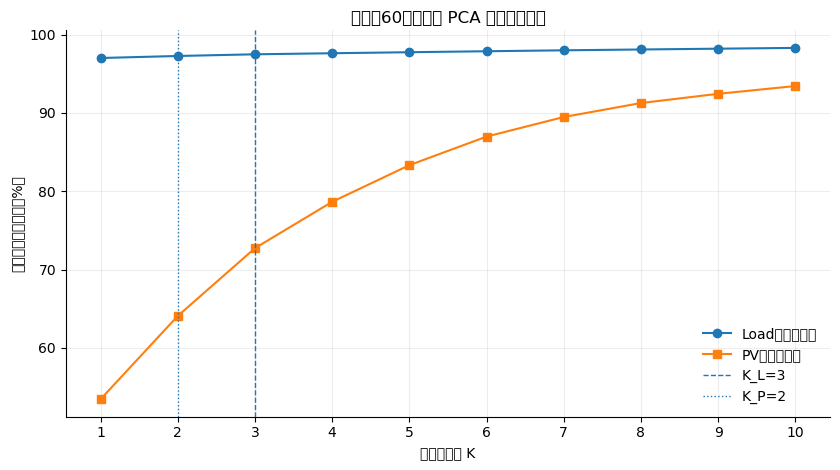

In [18]:
rep_date = pd.Timestamp("2025-09-01")
rep_d = np.where(DATES == rep_date)[0][0]
h0 = rep_d - CFG["window_days"]

def explained_variance_ratio(curves):
    X = curves - curves.mean(axis=0)
    _, s, _ = np.linalg.svd(X, full_matrices=False)
    eig = s ** 2
    return eig / eig.sum()

evr_l = explained_variance_ratio(LOAD[h0:rep_d])
evr_p = explained_variance_ratio(PV[h0:rep_d])

fig, ax = plt.subplots(figsize=(8.5, 4.8))
k = np.arange(1, 11)
ax.plot(k, np.cumsum(evr_l[:10]) * 100, marker="o", label="Load累计解释率")
ax.plot(k, np.cumsum(evr_p[:10]) * 100, marker="s", label="PV累计解释率")
ax.axvline(CFG["k_load"], linestyle="--", linewidth=1, label="K_L=3")
ax.axvline(CFG["k_pv"], linestyle=":", linewidth=1, label="K_P=2")
ax.set_xlabel("主成分个数 K")
ax.set_ylabel("累计解释方差比例（%）")
ax.set_title("代表性60日窗口的 PCA 累计解释方差")
ax.set_xticks(k)
ax.grid(alpha=.22)
ax.legend(frameon=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()


## 6. Sep–Dec 连续两周净负荷预测效果

该图直观展示冻结模型对净负荷日内波动的跟踪能力。


C:\Users\HP\AppData\Local\Temp\ipykernel_6976\1567628881.py:23: UserWarning: Glyph 36830 (\N{CJK UNIFIED IDEOGRAPH-8FDE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_6976\1567628881.py:23: UserWarning: Glyph 32493 (\N{CJK UNIFIED IDEOGRAPH-7EED}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_6976\1567628881.py:23: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_6976\1567628881.py:23: UserWarning: Glyph 38047 (\N{CJK UNIFIED IDEOGRAPH-949F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_6976\1567628881.py:23: UserWarning: Glyph 26102 (\N{CJK UNIFIED IDEOGRAPH-65F6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_6976\1567628881.py:23: UserWarning: Glyph 27573 (\N{CJK UNIFIED IDEOGRAPH-

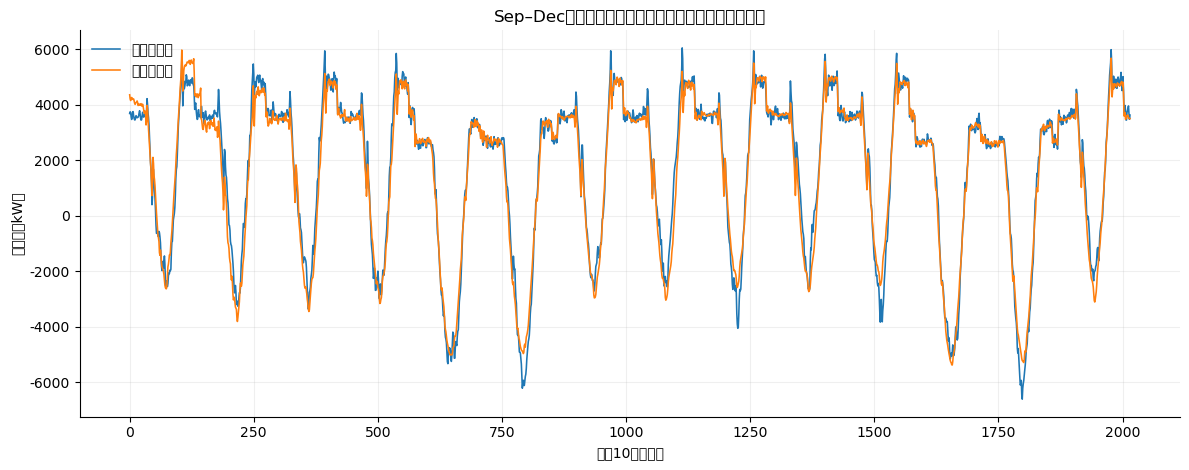

In [19]:
plot_start = pd.Timestamp("2025-09-01")
plot_end = pd.Timestamp("2025-09-14")

idx = np.where(
    (DATES >= plot_start) & (DATES <= plot_end)
)[0]

actual_net = (LOAD[idx] - PV[idx]).reshape(-1)
pred_net = (PRED_LOAD[idx] - PRED_PV[idx]).reshape(-1)

x = np.arange(len(actual_net))

fig, ax = plt.subplots(figsize=(12, 4.8))
ax.plot(x, actual_net, linewidth=1.15, label="实际净负荷")
ax.plot(x, pred_net, linewidth=1.15, label="预测净负荷")
ax.set_xlabel("连续10分钟时段")
ax.set_ylabel("净负荷（kW）")
ax.set_title("Sep–Dec样本外阶段：连续两周净负荷实际值与预测值")
ax.grid(alpha=.2)
ax.legend(frameon=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()


## 7. 分月 Net Load RMSE

分月评价用于判断最终误差是否由个别月份主导。  
注意：该图是**冻结模型评价**，不再用于反向调参。


,month,MAE_kW,RMSE_kW
0,9,286.4863,397.2503
1,10,209.7359,317.5891
2,11,149.7413,214.3247
3,12,162.6720,228.7225


C:\Users\HP\AppData\Local\Temp\ipykernel_6976\1927407700.py:30: UserWarning: Glyph 26376 (\N{CJK UNIFIED IDEOGRAPH-6708}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_6976\1927407700.py:30: UserWarning: Glyph 20221 (\N{CJK UNIFIED IDEOGRAPH-4EFD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_6976\1927407700.py:30: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_6976\1927407700.py:30: UserWarning: Glyph 65289 (\N{FULLWIDTH RIGHT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_6976\1927407700.py:30: UserWarning: Glyph 20923 (\N{CJK UNIFIED IDEOGRAPH-51BB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_6976\1927407700.py:30: UserWarning: Glyph 32467 (\N{CJK UNIFIED IDEOGRAPH

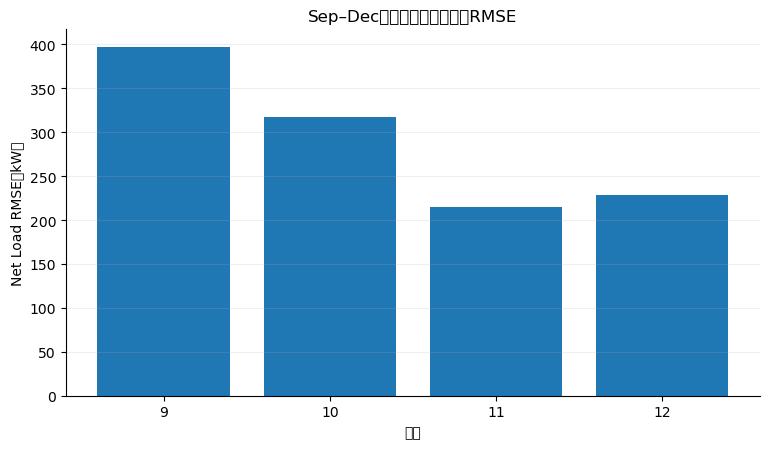

In [20]:
rows = []

for month in [9, 10, 11, 12]:
    idx = np.where(
        (DATES >= TEST_START)
        & (DATES <= TEST_END)
        & (DATES.month == month)
    )[0]

    y = LOAD[idx] - PV[idx]
    p = PRED_LOAD[idx] - PRED_PV[idx]

    rows.append({
        "month": month,
        "MAE_kW": np.mean(np.abs(y - p)),
        "RMSE_kW": np.sqrt(np.mean((y - p) ** 2)),
    })

monthly = pd.DataFrame(rows)
display(monthly.round(4))

fig, ax = plt.subplots(figsize=(7.8, 4.6))
ax.bar(monthly["month"].astype(str), monthly["RMSE_kW"])
ax.set_xlabel("月份")
ax.set_ylabel("Net Load RMSE（kW）")
ax.set_title("Sep–Dec冻结模型分月净负荷RMSE")
ax.grid(axis="y", alpha=.2)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()


## 8. 典型日：Load、PV 与 Net Load

下面自动选择 Sep–Dec 中净负荷日 RMSE 接近中位数的一天作为代表性日期。


C:\Users\HP\AppData\Local\Temp\ipykernel_6976\3405134808.py:29: UserWarning: Glyph 26102 (\N{CJK UNIFIED IDEOGRAPH-65F6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_6976\3405134808.py:29: UserWarning: Glyph 27573 (\N{CJK UNIFIED IDEOGRAPH-6BB5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_6976\3405134808.py:29: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_6976\3405134808.py:29: UserWarning: Glyph 65289 (\N{FULLWIDTH RIGHT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_6976\3405134808.py:29: UserWarning: Glyph 21151 (\N{CJK UNIFIED IDEOGRAPH-529F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_6976\3405134808.py:29: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH

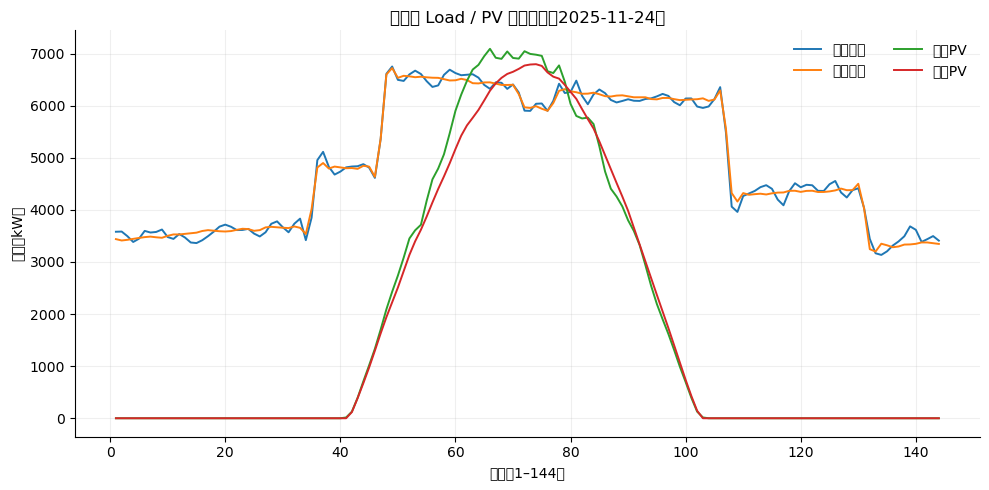

C:\Users\HP\AppData\Local\Temp\ipykernel_6976\3405134808.py:52: UserWarning: Glyph 26102 (\N{CJK UNIFIED IDEOGRAPH-65F6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_6976\3405134808.py:52: UserWarning: Glyph 27573 (\N{CJK UNIFIED IDEOGRAPH-6BB5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_6976\3405134808.py:52: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_6976\3405134808.py:52: UserWarning: Glyph 65289 (\N{FULLWIDTH RIGHT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_6976\3405134808.py:52: UserWarning: Glyph 20928 (\N{CJK UNIFIED IDEOGRAPH-51C0}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_6976\3405134808.py:52: UserWarning: Glyph 36127 (\N{CJK UNIFIED IDEOGRAPH

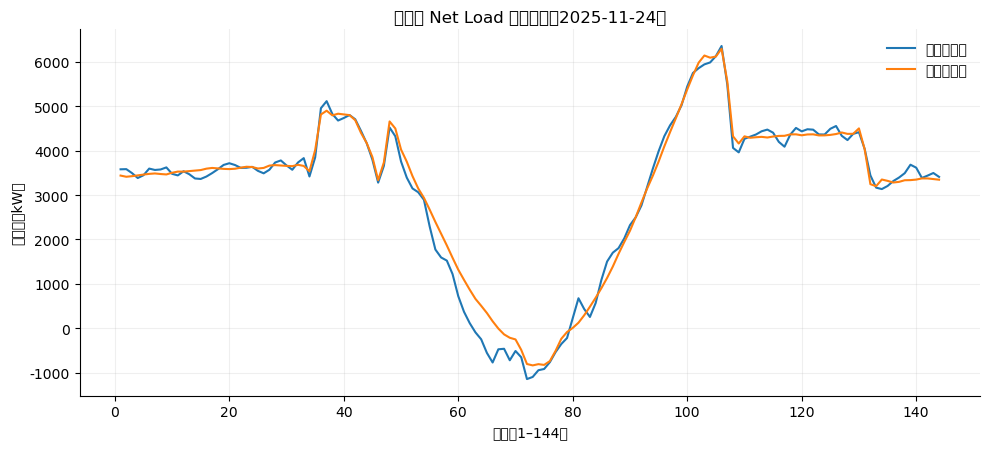

代表性日期: 2025-11-24


In [21]:
daily_rows = []

for d in TEST_IDX:
    y = LOAD[d] - PV[d]
    p = PRED_LOAD[d] - PRED_PV[d]
    daily_rows.append({
        "date": DATES[d],
        "rmse": np.sqrt(np.mean((y - p) ** 2)),
    })

daily_rmse = pd.DataFrame(daily_rows).sort_values("rmse").reset_index(drop=True)
rep_day = daily_rmse.iloc[len(daily_rmse)//2]["date"]
rep_d = np.where(DATES == rep_day)[0][0]

x = np.arange(1, 145)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x, LOAD[rep_d], linewidth=1.4, label="实际负荷")
ax.plot(x, PRED_LOAD[rep_d], linewidth=1.4, label="预测负荷")
ax.plot(x, PV[rep_d], linewidth=1.4, label="实际PV")
ax.plot(x, PRED_PV[rep_d], linewidth=1.4, label="预测PV")
ax.set_xlabel("时段（1–144）")
ax.set_ylabel("功率（kW）")
ax.set_title(f"典型日 Load / PV 预测对比（{rep_day.date()}）")
ax.grid(alpha=.2)
ax.legend(frameon=False, ncol=2)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 4.6))
ax.plot(
    x,
    LOAD[rep_d] - PV[rep_d],
    linewidth=1.5,
    label="实际净负荷",
)
ax.plot(
    x,
    PRED_LOAD[rep_d] - PRED_PV[rep_d],
    linewidth=1.5,
    label="预测净负荷",
)
ax.set_xlabel("时段（1–144）")
ax.set_ylabel("净负荷（kW）")
ax.set_title(f"典型日 Net Load 预测对比（{rep_day.date()}）")
ax.grid(alpha=.2)
ax.legend(frameon=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

print("代表性日期:", rep_day.date())


## 9. 导出最终点预测结果

导出的 CSV 可用于：

- 后续概率场景构造；
- 论文绘图；
- Codex / 独立审计；
- 与 `p2.py` 最终预测结果核对。

本 Notebook 不会覆盖 `result2.xlsx`。


In [22]:
OUT_DIR = ROOT / "results_final"
OUT_DIR.mkdir(parents=True, exist_ok=True)

rows = []
for d in range(len(DATES)):
    if not np.isfinite(PRED_LOAD[d]).all():
        continue
    for t in range(144):
        rows.append({
            "date": str(DATES[d].date()),
            "slot": t + 1,
            "actual_load_kw": float(LOAD[d, t]),
            "pred_load_kw": float(PRED_LOAD[d, t]),
            "actual_pv_kw": float(PV[d, t]),
            "pred_pv_kw": float(PRED_PV[d, t]),
            "actual_net_kw": float(LOAD[d, t] - PV[d, t]),
            "pred_net_kw": float(PRED_LOAD[d, t] - PRED_PV[d, t]),
        })

forecast_df = pd.DataFrame(rows)

forecast_path = OUT_DIR / "q2_frozen_point_forecast.csv"
summary_path = OUT_DIR / "q2_frozen_point_forecast_metrics.csv"
monthly_path = OUT_DIR / "q2_frozen_point_forecast_monthly.csv"

forecast_df.to_csv(
    forecast_path,
    index=False,
    encoding="utf-8-sig",
)

summary_table = pd.concat([
    dev_metrics.assign(period="development_May_Aug"),
    test_metrics.assign(period="independent_test_Sep_Dec"),
], ignore_index=True)

summary_table.to_csv(
    summary_path,
    index=False,
    encoding="utf-8-sig",
)

monthly.to_csv(
    monthly_path,
    index=False,
    encoding="utf-8-sig",
)

print("已导出：")
print(forecast_path)
print(summary_path)
print(monthly_path)


已导出：
e:\桌面\CUMCM_2026\q2\results_final\q2_frozen_point_forecast.csv
e:\桌面\CUMCM_2026\q2\results_final\q2_frozen_point_forecast_metrics.csv
e:\桌面\CUMCM_2026\q2\results_final\q2_frozen_point_forecast_monthly.csv


## 10. 最终结论

本 Notebook 对应第二问最终冻结的日曲线预测模块。

最终模型采用：

$$
\boxed{
W=60,\quad
K_L=3,\quad
K_P=2,\quad
h_L=\mathrm{lag1},\quad
h_P=\mathrm{lag1}+\mathrm{lag7}+\mathrm{mean7}
}
$$

以及：

$$
\boxed{
C_L=\mathrm{weekday7},\quad
C_P=\mathrm{annual1},\quad
\alpha_L=0.3,\quad
\alpha_P=10
}
$$

Sep–Dec 的最终样本外点预测指标应为约：

$$
\boxed{
\mathrm{Net\ MAE}
=
201.897\ \mathrm{kW}
}
$$

$$
\boxed{
\mathrm{Net\ RMSE}
=
298.367\ \mathrm{kW}
}
$$

后续风险场景、$q^*=0.85$ 与储能调度由最终 `p2.py` 统一完成。
